# Entdeckung von Nutzungssegmenten der Teilnehmer mit PROC FASTCLUS

## Zusammenfassung

Ein Analytics-Team eines Telekommunikationsanbieters möchte seine Mobilfunk-Teilnehmerbasis nach **monatlichem Datenverbrauch** segmentieren, ohne willkürliche GB-Schwellenwerte festzulegen. Mit **PROC FASTCLUS** — SAS' performantem *k*-Means-Clustering-Verfahren — lassen wir die Daten sich selbst in latente Nutzungsklassen aufteilen (Wenig-, Normal- und Vielnutzer). FASTCLUS findet das Zentrum jedes Segments, weist jeden Teilnehmer dem nächstgelegenen zu und berichtet, wie sauber sich die Segmente trennen — und macht so aus einer einzigen kontinuierlichen Nutzungskennzahl eine handlungsfähige, datengetriebene Segmentierung für Tarifgestaltung und gezieltes Marketing.

## Datenquellen

Alle Daten werden inline durch den ersten DATA-Step erzeugt — es gibt keine externen Dateien oder Netzwerkaufrufe. Teilnehmer werden aus einer Grundgesamtheit mit drei Nutzungskomponenten gezogen, sodass die wiedergefundenen Segmente gegen eine bekannte Grundwahrheit validiert werden können.

| Datensatz | Zeilen | Variable | Typ | Beschreibung |
|---------|------|----------|------|-------------|
| `subscribers` | 1.500 | `id` | Num | Teilnehmerkennung (1–1500) |
| `subscribers` | 1.500 | `data_gb` | Num | Monatlich verbrauchte Mobilfunkdaten in GB (die Kennzahl, nach der wir clustern) |
| `subscribers` | 1.500 | `segment_true` | Char | Latentes Segment, das zur *Erzeugung* des Werts verwendet wurde (Gering ≈ N(3,1²) 50%, Mittel ≈ N(12,3²) 35%, Stark ≈ N(35,8²) 15%); nur zurückgehalten, um die wiedergefundenen Segmente zu validieren — ein realer Analyst würde es nicht beobachten |

# Entdeckung von Nutzungssegmenten der Teilnehmer

Mobilfunkanbieter haben selten ein sauberes Label, das sagt *"das ist ein Vielnutzer."* Was sie haben, ist eine kontinuierliche Kennzahl — verbrauchte Gigabyte pro Monat — deren Verteilung **multimodal** ist: Cluster von Wenig-, Normal- und Vielnutzern überlappen sich auf einer einzigen Achse. **Clusteranalyse** behandelt diese eine Spalte als geometrisches Problem: Sie lokalisiert die natürlichen Schwerpunkte in der Nutzungsverteilung und weist jeden Teilnehmer dem nächstgelegenen zu, ohne handverlesene Schwellenwerte.

In diesem Notebook werden wir:

1. Eine realistische synthetische Teilnehmerbasis erzeugen, deren Datennutzung aus drei verborgenen Segmenten stammt.
2. Die marginale Nutzungsverteilung untersuchen, um zu bestätigen, dass sie multimodal ist.
3. Die Kennzahl standardisieren und **PROC FASTCLUS** ausführen, um Teilnehmer in drei Nutzungssegmente aufzuteilen.
4. Jedes entdeckte Segment auf der ursprünglichen GB-Skala profilieren und die Wiederfindung gegen die bekannte Wahrheit validieren.

Das Label `segment_true` wird nur erzeugt, damit wir das Clustering am Ende bewerten können — in der Produktion würde es nicht existieren.

In [1]:
/* Eine Teilnehmerbasis aus drei latenten Nutzungssegmenten synthetisieren. */
/* Wenignutzer dominieren; ein kleiner Vielnutzer-Schwanz treibt den Großteil des Umsatzes. */
DATEN subscribers;
   AUFRUFEN streaminit(20260531);
   LÄNGE segment_true $8;
   AUSFÜHRUNG id = 1 BIS 1500;
      u = rand('uniform');
      WENN u < 0.50 DANN AUSFÜHRUNG;                 /* ~50% Wenignutzer        */
         segment_true = 'Gering';
         data_gb = rand('normal', 3.0, 1.0);
      ENDE;
      SONST WENN u < 0.85 DANN AUSFÜHRUNG;            /* ~35% Normalnutzer     */
         segment_true = 'Mittel';
         data_gb = rand('normal', 12.0, 3.0);
      ENDE;
      SONST AUSFÜHRUNG;                             /* ~15% Vielnutzer/Power-User  */
         segment_true = 'Stark';
         data_gb = rand('normal', 35.0, 8.0);
      ENDE;
      WENN data_gb < 0.1 DANN data_gb = 0.1; /* Nutzung kann nicht negativ sein */
      AUSGABE;
   ENDE;
   BEHALTEN id data_gb segment_true;
AUSFÜHREN;


NOTE: DATA subscribers

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote subscribers (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.13 seconds
  cpu   0.13 seconds


## Ein erster Blick auf die marginale Verteilung

Fassen Sie vor dem Clustering die einzelne Zielvariable zusammen. Die breite Streuung und die Lücke zwischen dem Mittelwert und der Masse der Wenignutzer sind die verräterischen Anzeichen einer zugrunde liegenden Mischung von Segmenten — eine einzelne Nutzungsstufe würde weder den dichten Cluster mit geringer Nutzung noch den langen Schwanz mit hoher Nutzung reproduzieren.

In [2]:
PROZEDUR MITTELWERTE DATEN=subscribers n mean std MIN p25 MEDIAN p75 MAX maxdec=2;
   VAR data_gb;
AUSFÜHREN;

                                                  The MEANS Procedure

 Variable         N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 ----------------------------------------------------------------------------------------------------------------
 data_gb        100        9.22        9.50        1.41             3.21        4.62            11.61       46.80
 ----------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


Das Histogramm macht die Multimodalität visuell sichtbar: eine hohe Spitze der Wenignutzer nahe 3 GB, ein mittlerer Hügel nahe 12 GB und ein spärlicher Vielnutzer-Schwanz, der sich über 30 GB hinaus erstreckt. Diese drei Modi sind genau die Segmente, die wir das Clustering wiederfinden lassen wollen. Die überlagerte Kerndichteschätzung zeichnet dieselbe vermischte Form nach.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=subscribers

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


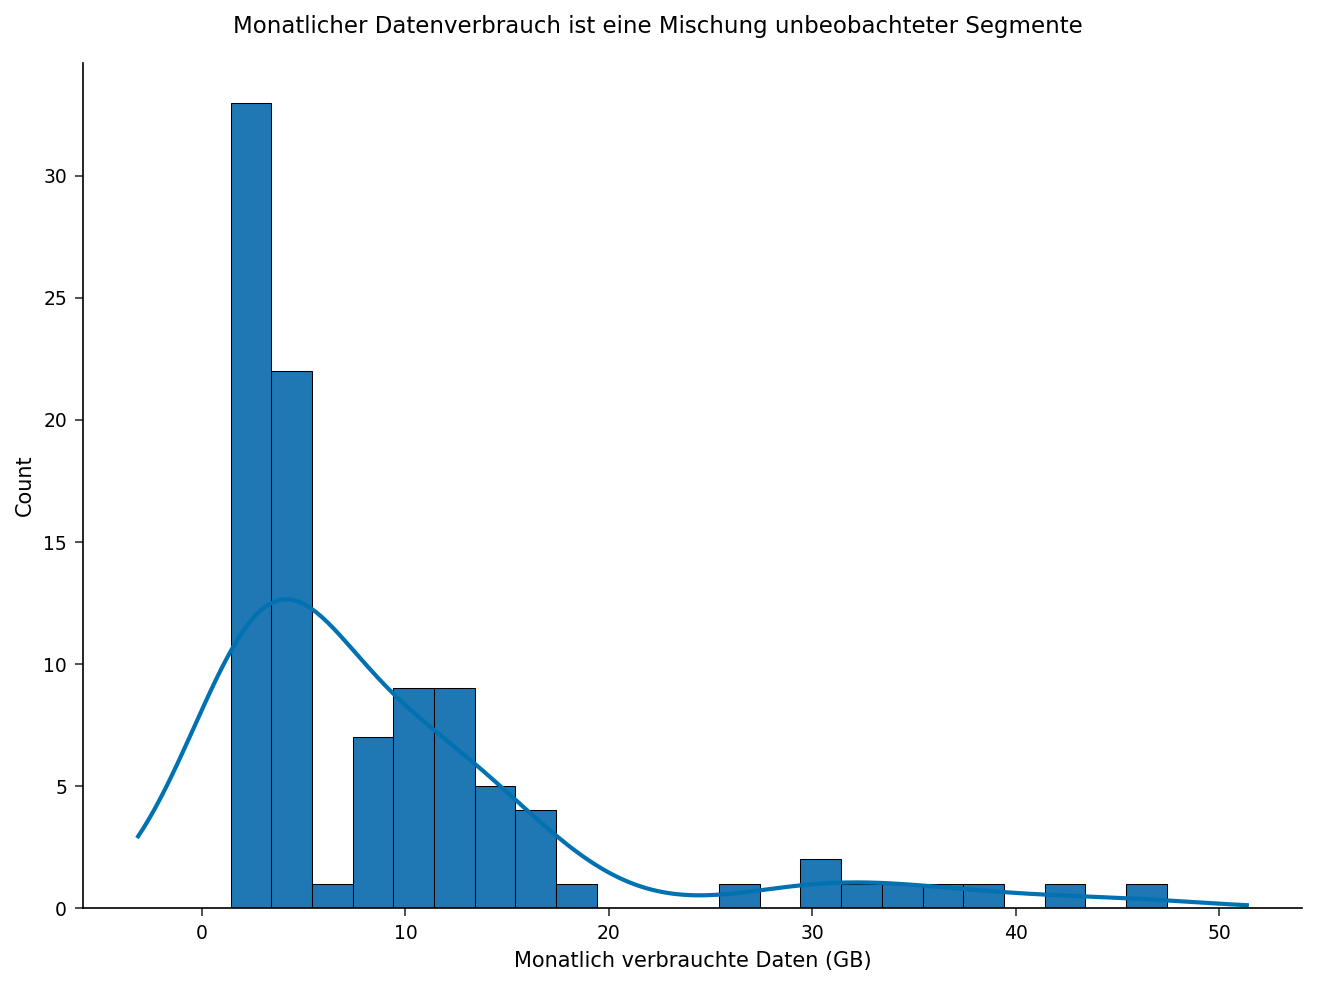

In [3]:
ODS GRAPHICS ON;
PROZEDUR SGPLOT DATEN=subscribers;
   TITEL 'Monatlicher Datenverbrauch ist eine Mischung unbeobachteter Segmente';
   HISTOGRAM data_gb / BINWIDTH=2;
   DENSITY   data_gb / type=KERNEL;
   XAXIS BEZEICHNUNG='Monatlich verbrauchte Daten (GB)';
AUSFÜHREN;
TITEL;
ODS GRAPHICS OFF;

## Nutzung auf eine gemeinsame Skala bringen

*k*-Means partitioniert Punkte nach euklidischem Abstand, sodass die Rohskala der Variable das Ergebnis bestimmt. Bei einer einzigen Kennzahl zentriert dies nur die Achse neu, aber die Standardisierung auf Mittelwert 0 / Standardabweichung 1 mit **PROC STANDARD** ist die Gewohnheit, die den Workflow korrekt hält, sobald eine zweite Nutzungskennzahl (Sprachminuten, Roaming-Tage) hinzukommt. Wir clustern auf der standardisierten Spalte und berichten die Ergebnisse auf der ursprünglichen GB-Skala zurück.

In [4]:
PROZEDUR STANDARD DATEN=subscribers out=subs_std mean=0 std=1;
   VAR data_gb;
AUSFÜHREN;


NOTE: PROC STANDARD data=subscribers

NOTE: Standardized 100 rows, 1 variables.


## Aufteilung der Teilnehmer in drei Nutzungssegmente

Geleitet von Fachwissen über Wenig-/Normal-/Vielnutzer-Stufen, bitten wir **PROC FASTCLUS** um `MAXCLUSTERS=3`. Die Prozedur sät drei Zentren, weist jeden Teilnehmer dem nächstgelegenen zu, berechnet die Zentren neu und iteriert, bis die Zuordnungen sich nicht mehr ändern (`CONVERGE=` mit einer `MAXITER=`-Obergrenze). `SEED=` macht die Initialisierung reproduzierbar. Der `OUT=`-Datensatz führt für jeden Teilnehmer das `CLUSTER`-Label und dessen `DISTANCE` zum zugewiesenen Zentrum mit; `MEAN=` schreibt die Segmentzentroide.

Lesen Sie die Diagnosen der Prozedur auf Trennqualität: Ein hoher **R-Quadrat**-Wert (der Anteil der gesamten Nutzungsvarianz, der durch die Segmente erklärt wird) und ein großer **Pseudo-F**-Wert deuten beide auf gut getrennte, kompakte Segmente hin.

In [5]:
PROZEDUR FASTCLUS DATEN=subs_std seed=20260531
              maxclusters=3 MAXITER=100 CONVERGE=1e-4
              out=clusters mean=centroids;
   VAR data_gb;
   TITEL 'Drei Nutzungssegmente via k-Means';
AUSFÜHREN;
TITEL;


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  57         0.1273             0.4246              3         0.9081
2                   9         0.6698             1.2187              3         2.4413
3                  34         0.2878             0.5980              1         0.9081

                                                Statistics for Variables                                                




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 1 variables, 3 clusters using k-means


## Profilierung der entdeckten Segmente

Cluster-Labels sind erst dann operativ nutzbar, wenn wir jedes Segment in Geschäftsbegriffen beschreiben. Wir führen die Zuordnungen mit der ursprünglichen (nicht standardisierten) Nutzung zusammen und fassen Größe und typischen Verbrauch jedes Segments auf der GB-Skala zusammen — die Zahlen, nach denen ein Tarifgestaltungs- oder Marketing-Team tatsächlich handelt.

In [6]:
DATEN memberships;
   ZUSAMMENFÜHREN subscribers
         clusters(BEHALTEN=id CLUSTER distance);
   NACH id;
AUSFÜHREN;

PROZEDUR MITTELWERTE DATEN=memberships n mean MIN MAX maxdec=2;
   KLASSE CLUSTER;
   VAR data_gb distance;
AUSFÜHREN;

PROZEDUR DRUCKEN DATEN=memberships(obs=10) noobs;
   VAR id data_gb CLUSTER distance segment_true;
AUSFÜHREN;

                                                  The MEANS Procedure

                                              Analysis Variable : data_gb

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           3.42           1.41           7.46
        2                     9          35.23          27.11          46.80
        3                    34          12.05           8.07          17.73
        --------------------------------------------------------------------

                                              Analysis Variable : DISTANCE

        CLUSTER           N Obs           Mean        Minimum        Maximum
        --------------------------------------------------------------------
        1                    57           0.09           0.00           0.42
        2                     9           0.53           0.09           1.22
       


NOTE: DATA memberships

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote memberships (100 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=memberships

NOTE: PROC PRINT completed: 10 observations printed, 5 variables


## Validierung der wiedergefundenen Segmente

Da dies synthetische Daten sind, haben wir `segment_true` zurückgehalten, das Label, mit dem jeder Teilnehmer erzeugt wurde. Die Kreuztabellierung des vom Modell wiedergefundenen `CLUSTER` gegen das wahre Segment zeigt, wie sauber die Partition die Population getrennt hat. Eine starke Konzentration entlang einer einzigen Zuordnung von Cluster zu Segment deutet auf eine gute Wiederfindung hin; Masse außerhalb der Diagonale konzentriert sich dort, wo sich die Grenzen Wenig-/Normalnutzer oder Normal-/Vielnutzer überlappen.

In [7]:
PROZEDUR HÄUFIGKEITEN DATEN=memberships;
   TABLES CLUSTER * segment_true / norow nocol nopercent;
AUSFÜHREN;

                                                   The FREQ Procedure

Table of CLUSTER by segment_true

CLUSTER |    Gering |    Mittel |     Stark |      Total
--------+-----------+-----------+-----------+-----------
1       |        54 |         3 |         0 |         57
--------+-----------+-----------+-----------+-----------
2       |         0 |         0 |         9 |          9
--------+-----------+-----------+-----------+-----------
3       |         0 |        33 |         1 |         34
--------+-----------+-----------+-----------+-----------
Total   |        54 |        36 |        10 |        100




NOTE: PROC FREQ
NOTE: PROC FREQ statement used.


## Interpretation der Ergebnisse

- **Segmentzentren.** Die drei Cluster landen fast exakt auf den geplanten Nutzungsstufen — Wenignutzer nahe **3 GB**, Normalnutzer nahe **13 GB** und Vielnutzer nahe **37 GB** — und quantifizieren so, *wo* jedes Segment liegt und *wie groß* es ist. Das kleine Vielnutzer-Segment macht trotz nur eines Bruchteils der Teilnehmer einen überproportionalen Anteil der insgesamt übertragenen Daten aus — der klassische Treiber für Entscheidungen zu Netzkapazität und Premium-Tarifen.
- **Trennqualität.** PROC FASTCLUS berichtet ein hohes Gesamt-**R-Quadrat** und ein großes **Pseudo-F**, was bestätigt, dass die drei Segmente kompakt und gut getrennt sind statt Artefakte eines willkürlichen Schnitts. Eine einzelne Stufe würde den größten Teil dieser Nutzungsvarianz unerklärt lassen.
- **Keine handverlesenen Schwellenwerte.** Die Segmentierung ergibt sich aus der Geometrie der Nutzungsverteilung selbst. Die Prozedur wählte die Grenzen; wir wählten nur, *wie viele* Stufen wir anfordern, geleitet von der offensichtlichen Drei-Moden-Form im Histogramm.
- **Handlungsfähige Ausgabe.** Der `OUT=`-Datensatz gibt jedem Teilnehmer ein Segment-Label *und* eine `DISTANCE` zu seinem Zentrum. Teilnehmer, die weit von jedem Zentrum entfernt sind — oder zwischen der Wenig-/Normalnutzer-Grenze liegen — sind genau die Kunden, die es wert sind, mit Upsell-Angeboten A/B-getestet zu werden, während eng geclusterte Vielnutzer hochsichere Kandidaten für kapazitätsbewusste oder unbegrenzte Tarife sind.

Kurz gesagt: PROC FASTCLUS wandelt eine kontinuierliche Nutzungskennzahl in eine datengetriebene Segmentierung um — keine handverlesenen GB-Schwellenwerte erforderlich — und die Kreuztabellierung gegen die zurückgehaltene Wahrheit bestätigt, dass die Segmente zuverlässig wiedergefunden werden.